# Grocery Demand Forecasting using Machine Learning

## Time Series Forecasting using ARIMA, Prophet & XGBoost

## Project Overview

This project aims to develop and compare various time series forecasting models to predict grocery sales for a specific store and product family using the Kaggle "Store Sales - Time Series Forecasting" dataset. The goal is to identify the most accurate model for demand forecasting, which can help in inventory management, supply chain optimization, and promotional planning.

## Business Problem

Accurate demand forecasting is crucial for retailers to manage inventory, reduce waste, and maximize sales. In the context of grocery stores, predicting sales for specific items at individual locations can be challenging due to complex patterns like seasonality, promotions, and external events. This notebook focuses on forecasting the sales of 'GROCERY I' products at 'Store 1' to demonstrate a practical approach using machine learning and statistical time series models.

In [4]:
import pandas as pd

df = pd.read_csv('/content/train.csv', parse_dates=['date'])

print("Full dataset shape:", df.shape)
print("Full dataset date range:", df['date'].min(), "to", df['date'].max())
print(df.head())

subset_df = df[
    (df['store_nbr'] == 1) &
    (df['family'] == 'GROCERY I')
].copy()

subset_df = subset_df.sort_values('date').reset_index(drop=True)

print("Subset shape:", subset_df.shape)
print("Subset date range:", subset_df['date'].min(), "to", subset_df['date'].max())

Full dataset shape: (3000888, 6)
Full dataset date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
Subset shape: (1684, 6)
Subset date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00


## Data Loading and Initial Inspection

## Data Cleaning and Preprocessing

## Exploratory Data Analysis (EDA)

In [8]:
# Data Cleaning and Preprocessing for Time Series

# Recreate subset_df from df to ensure correct starting state for cleaning
# This step is crucial if the cell is re-run after subset_df's index has been set.
subset_df = df[
    (df['store_nbr'] == 1) &
    (df['family'] == 'GROCERY I')
].copy()

subset_df = subset_df.sort_values('date').reset_index(drop=True)

# Now proceed with cleaning
# Drop unnecessary columns 'id', 'store_nbr', 'family' as we've already filtered
# Keep 'date', 'sales', 'onpromotion'
subset_df = subset_df.loc[:, ['date', 'sales', 'onpromotion']]

# Set 'date' as index for time series operations
subset_df.set_index('date', inplace=True)

# Ensure the time series has a daily frequency and fill any missing dates
# This will introduce NaNs for dates with no entries, which we will handle.
subset_df = subset_df.asfreq('D')

# Fill NaNs created by asfreq(). Assume 0 sales and 0 onpromotion for missing days.
subset_df['sales'] = subset_df['sales'].fillna(0)
subset_df['onpromotion'] = subset_df['onpromotion'].fillna(0)

# Convert 'onpromotion' to integer type if it's not already
subset_df['onpromotion'] = subset_df['onpromotion'].astype(int)

print("Preprocessed subset_df shape:", subset_df.shape)
print("Preprocessed subset_df date range:", subset_df.index.min(), "to", subset_df.index.max())
print("Missing sales values after processing (should be 0):", subset_df['sales'].isna().sum())
print("Missing onpromotion values after processing (should be 0):", subset_df['onpromotion'].isna().sum())
print("\nPreprocessed subset_df head:")
print(subset_df.head())

Preprocessed subset_df shape: (1688, 2)
Preprocessed subset_df date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Missing sales values after processing (should be 0): 0
Missing onpromotion values after processing (should be 0): 0

Preprocessed subset_df head:
             sales  onpromotion
date                           
2013-01-01     0.0            0
2013-01-02  2652.0            0
2013-01-03  2121.0            0
2013-01-04  2056.0            0
2013-01-05  2216.0            0


#### Clarification on Missing Dates and Zero-Fill Assumption

After reindexing the time series to a complete daily date range, a small number of missing calendar dates were introduced. For this project, these missing dates were assigned zero sales as a modeling assumption to maintain a continuous daily time series. These values should be interpreted as imputed values rather than confirmed zero-sales observations.

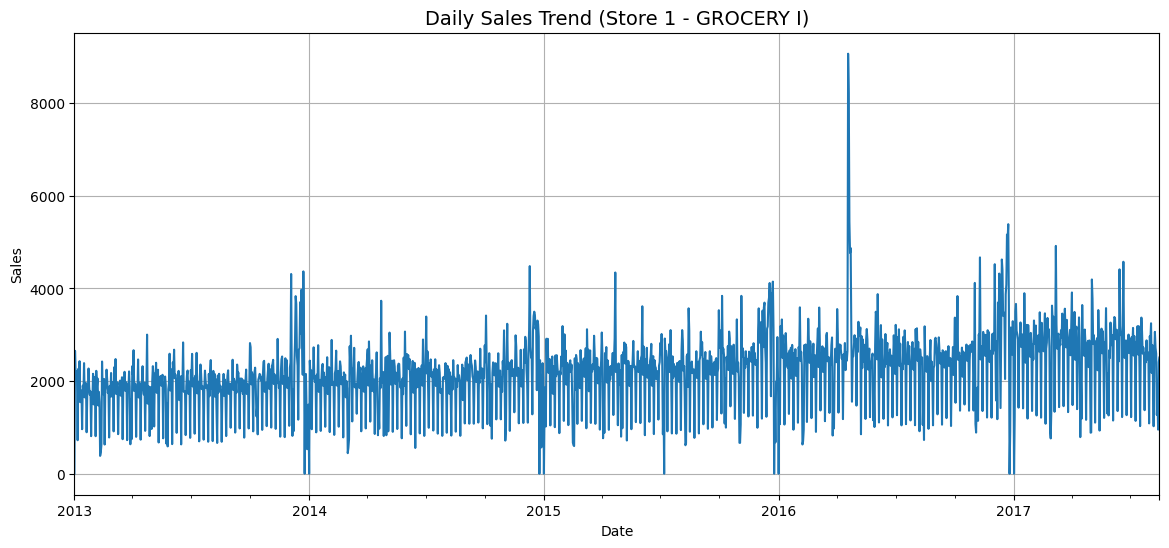

In [9]:
import matplotlib.pyplot as plt

# Plotting Daily Sales Trend after preprocessing
plt.figure(figsize=(14,6))
subset_df['sales'].plot()
plt.title('Daily Sales Trend (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

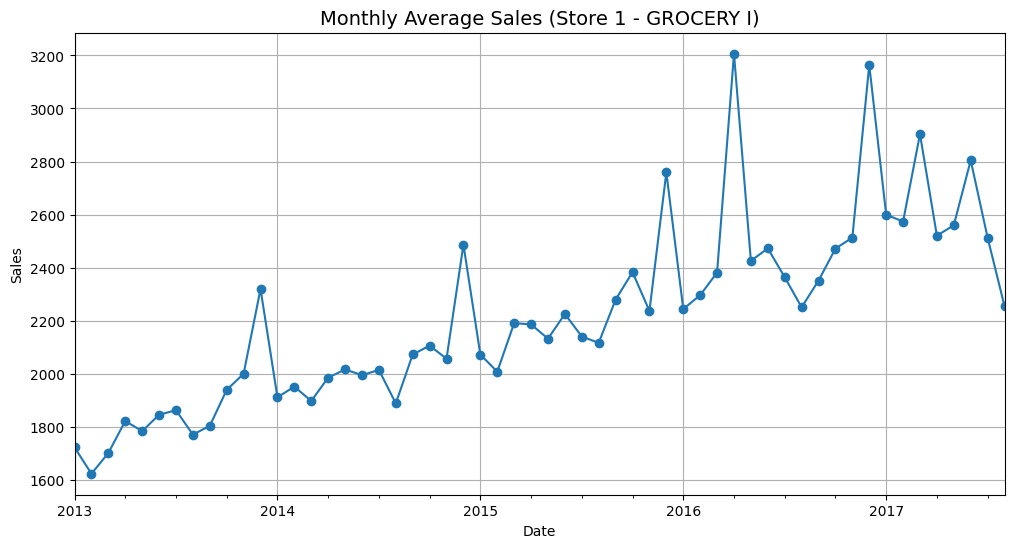

In [11]:
# Monthly average sales
# subset_df already has 'date' as DatetimeIndex, so we can directly resample.
monthly = subset_df['sales'].resample('ME').mean()

plt.figure(figsize=(12, 6))
monthly.plot(marker='o')
plt.title('Monthly Average Sales (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True)
plt.show()

In [13]:
# This cell is superseded by a more descriptive 'Average Sales by Day of Week' plot in cell E1kTqv5tdS4- and has been cleared.

In [14]:
# This cell is superseded by a more refined 'Sales Distribution: Promotion vs No Promotion' plot in cell IPCkdnkjdfrl and has been cleared.

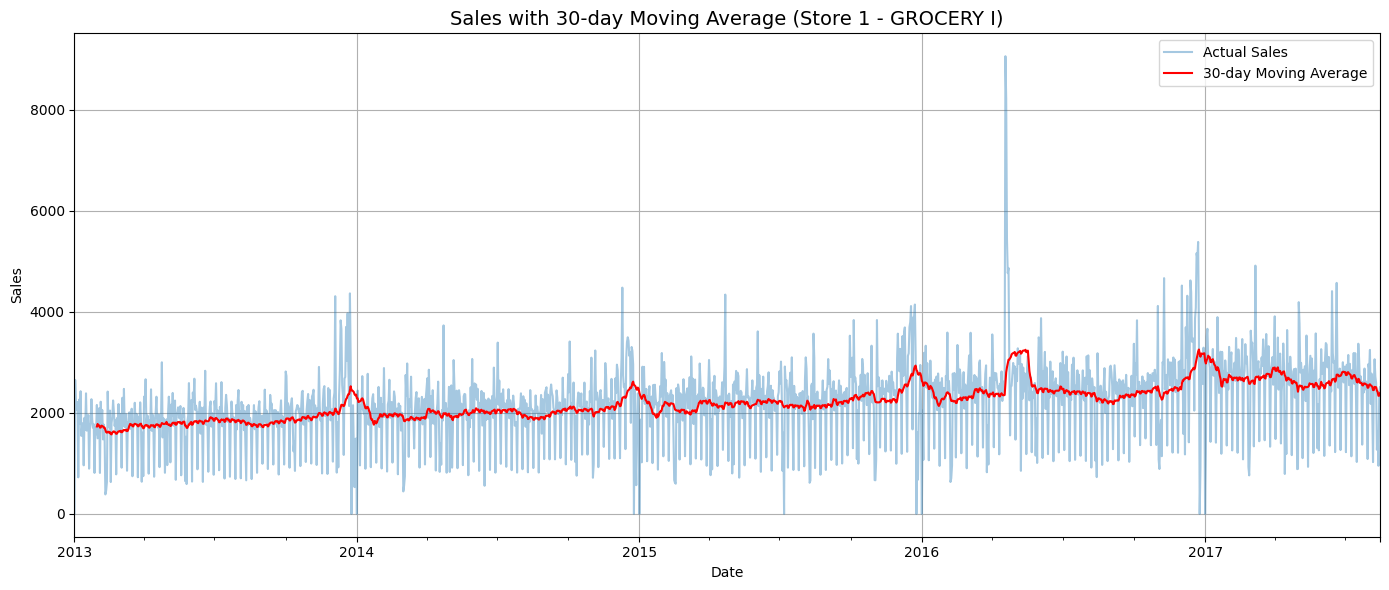

In [19]:
import matplotlib.pyplot as plt

# 30-day rolling mean for the full preprocessed subset_df
plt.figure(figsize=(14, 6))
subset_df['sales'].plot(alpha=0.4, label='Actual Sales')
subset_df['sales'].rolling(window=30).mean().plot(label='30-day Moving Average', color='red')
plt.title('Sales with 30-day Moving Average (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
# This cell is a duplicate of the daily sales trend plot and has been cleared.
# The main daily sales plot is in cell 04cee17a, which has been updated to use the correct data.

In [12]:
# This cell is a duplicate of the monthly average sales plot and has been cleared.
# The main monthly average sales plot is in cell ksohEHh5Ng47, which has been updated to use the correct data.

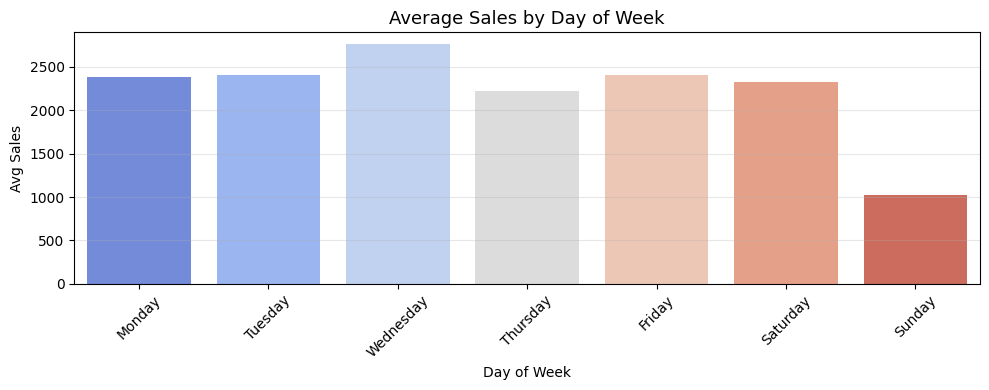

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Add weekday column (0=Monday, 6=Sunday) directly using subset_df's index
weekday_avg = subset_df.groupby(subset_df.index.day_name())['sales'].mean().reindex([
    'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
])

plt.figure(figsize=(10, 4))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values, hue=weekday_avg.index, palette='coolwarm', legend=False)
plt.title('Average Sales by Day of Week', fontsize=13)
plt.xlabel('Day of Week')
plt.ylabel('Avg Sales')
plt.xticks(rotation=45)
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

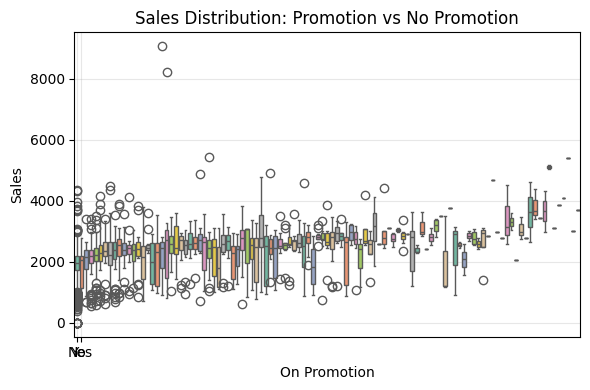

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.boxplot(x='onpromotion', y='sales', data=subset_df, hue='onpromotion', palette='Set2', legend=False)
plt.title('Sales Distribution: Promotion vs No Promotion', fontsize=12)
plt.xticks([0, 1], ['No', 'Yes'])
plt.xlabel('On Promotion')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

holidays_file_path = '/content/holidays_events.csv'

if os.path.exists(holidays_file_path):
    # Load holiday data
    holidays = pd.read_csv(holidays_file_path, parse_dates=['date'])

    # Reset index of subset_df to merge on 'date' column
    subset_df_for_merge = subset_df.reset_index()

    # Merge holiday info
    holiday_merge = pd.merge(
        subset_df_for_merge,
        holidays[['date', 'type']],
        how='left',
        on='date'
    )

    # Add holiday flag
    holiday_merge['is_holiday'] = holiday_merge['type'].notna().astype(int)

    # Compare sales on holiday vs non-holiday
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='is_holiday', y='sales', data=holiday_merge, hue='is_holiday', palette='Paired', legend=False)
    plt.title('Sales on Holidays vs Non-Holidays')
    plt.xticks([0, 1], ['Non-Holiday', 'Holiday'])
    plt.xlabel('Is Holiday')
    plt.ylabel('Sales')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f"Warning: The file '{holidays_file_path}' was not found. Skipping holiday sales analysis.")
    print("Please upload 'holidays_events.csv' to /content/ if you wish to include this analysis.")

Please upload 'holidays_events.csv' to /content/ if you wish to include this analysis.


<Figure size 1000x400 with 0 Axes>

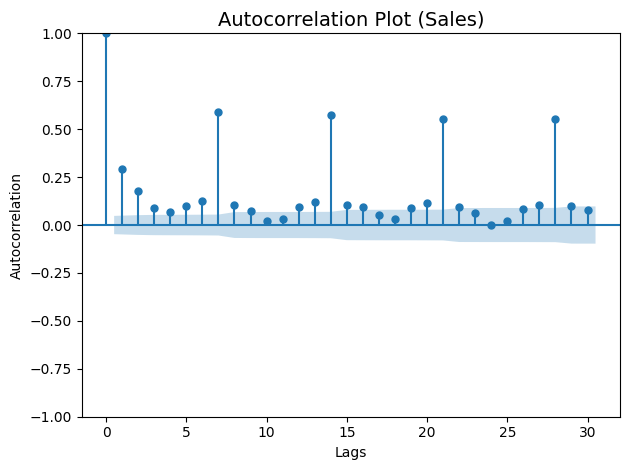

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Autocorrelation Plot of Sales
plt.figure(figsize=(10, 4))
plot_acf(subset_df['sales'], lags=30)
plt.title('Autocorrelation Plot (Sales)', fontsize=14)
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.tight_layout()
plt.show()

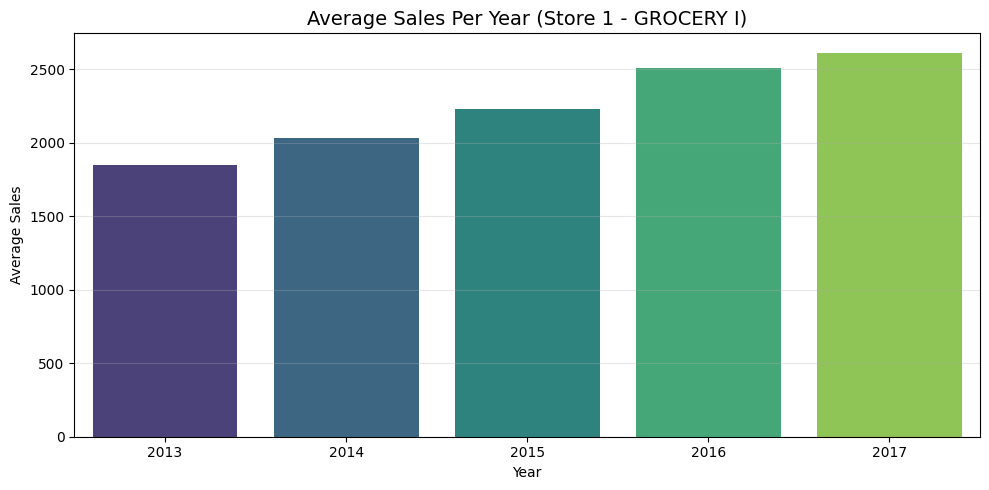

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract year from the index of subset_df
subset_df['year'] = subset_df.index.year

# Group and plot average sales by year
yearly_avg = subset_df.groupby('year')['sales'].mean()

plt.figure(figsize=(10, 5))
sns.barplot(x=yearly_avg.index.astype(str), y=yearly_avg.values, hue=yearly_avg.index.astype(str), palette='viridis', legend=False)
plt.title('Average Sales Per Year (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Sales')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Drop the 'year' column if it's not needed for subsequent steps to keep subset_df clean
subset_df.drop('year', axis=1, inplace=True, errors='ignore')

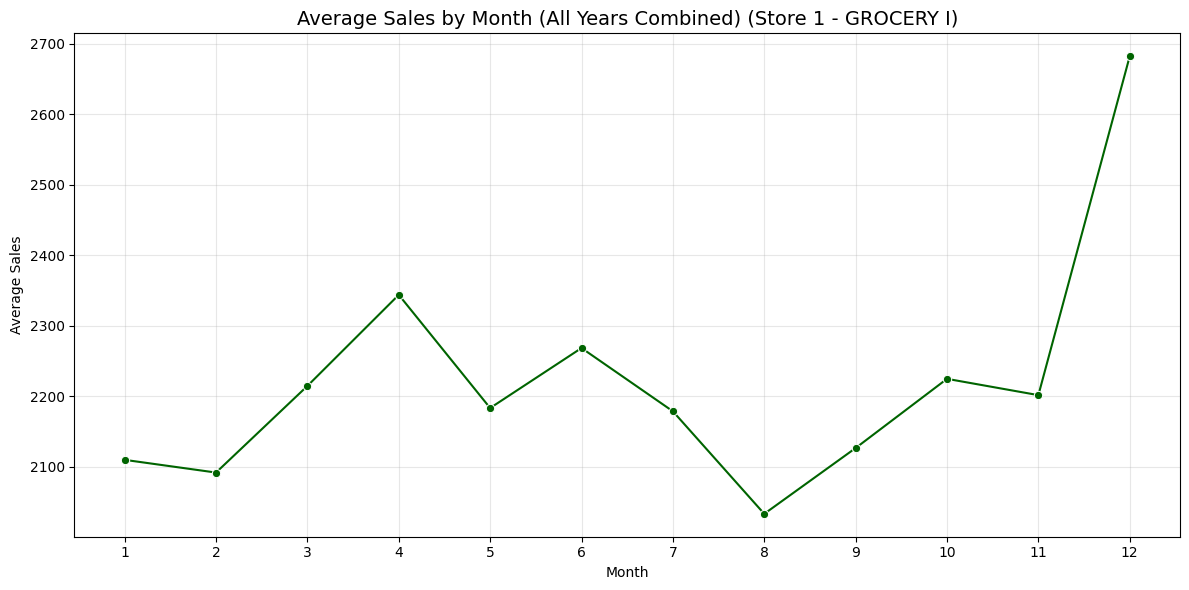

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract month from the index of subset_df
subset_df['month'] = subset_df.index.month

# Group and plot average sales by month
monthly_avg = subset_df.groupby('month')['sales'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=monthly_avg.index, y=monthly_avg.values, marker='o', color='darkgreen')
plt.title('Average Sales by Month (All Years Combined) (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drop the 'month' column if it's not needed for subsequent steps to keep subset_df clean
subset_df.drop('month', axis=1, inplace=True, errors='ignore')

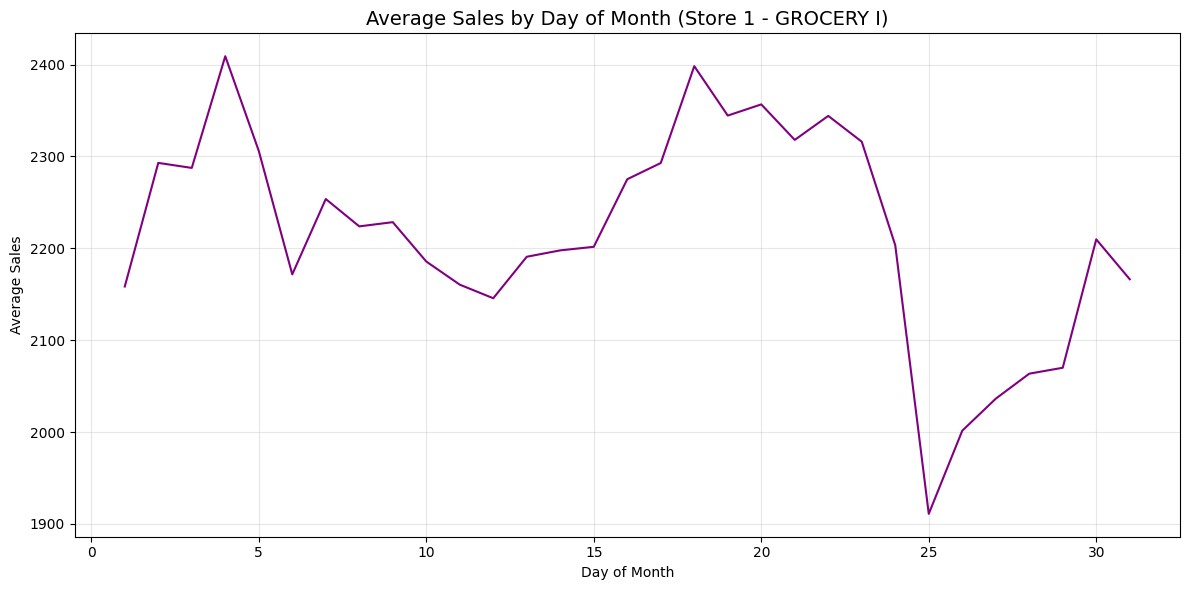

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract day from the index of subset_df
subset_df['day'] = subset_df.index.day

# Group and plot average sales by day of month
day_avg = subset_df.groupby('day')['sales'].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(x=day_avg.index, y=day_avg.values, color='purple')
plt.title('Average Sales by Day of Month (Store 1 - GROCERY I)', fontsize=14)
plt.xlabel('Day of Month')
plt.ylabel('Average Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Drop the 'day' column if it's not needed for subsequent steps to keep subset_df clean
subset_df.drop('day', axis=1, inplace=True, errors='ignore')

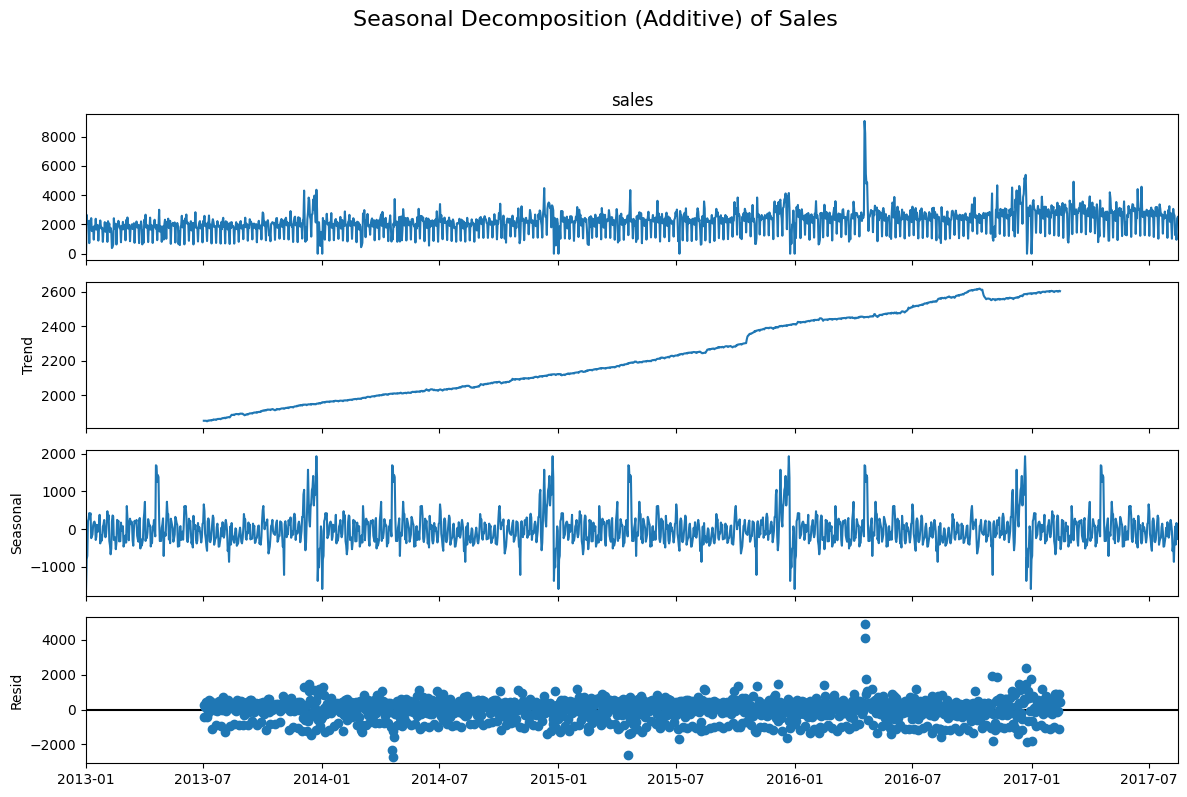

In [24]:
from statsmodels.tsa.seasonal import seasonal_decompose
import pandas as pd
import matplotlib.pyplot as plt

# subset_df already has 'date' as DatetimeIndex and is cleaned.
# No need to copy or re-set index.
ts = subset_df['sales']

# Seasonal decomposition requires a series with a frequency.
# Since subset_df is already .asfreq('D'), its index has a frequency.
# Ensure no NaNs before decomposition (handled during cleaning, but as a safeguard)
# Fill any remaining NaNs with 0 (or another appropriate strategy)
ts = ts.fillna(0)

# Decompose
# seasonal_decompose requires at least two full periods of data. For a period of 365, this means ~730 days.
# Check if there's enough data before attempting decomposition.
if len(ts) >= 2 * 365:
    # Use model='additive' as sales tend to be additive over time for Grocery I
    decomp = seasonal_decompose(ts, model='additive', period=365)

    # Plot
    fig = decomp.plot()
    fig.set_size_inches(12, 8)
    plt.suptitle('Seasonal Decomposition (Additive) of Sales', y=1.02, fontsize=16) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print(f"Not enough data points ({len(ts)}) for seasonal decomposition with period 365. Requires at least {2 * 365} days.")


## Time Series Preparation & Train-Test Split

In [27]:
import pandas as pd

# subset_df is already prepared with 'date' as index and daily frequency
# We will directly use subset_df, no need for temporary copies or re-indexing.
data = subset_df[['sales']]

# Define the split date
# Given the data spans from 2013-01-01 to 2017-08-15,
# a common practice is to reserve the last few months or a year for testing.
# Let's use a split point around early 2017 to have a good test period.
# For example, splitting at '2017-01-01' will give ~7.5 months for testing.
split_date = '2017-01-01'

# Check if the split date is valid within the data range
if pd.to_datetime(split_date) < data.index.min() or pd.to_datetime(split_date) > data.index.max():
    print(f"Warning: The chosen split_date '{split_date}' is outside the data range.")
    print(f"Data range: {data.index.min().strftime('%Y-%m-%d')} to {data.index.max().strftime('%Y-%m-%d')}")
    # Adjust split_date to be 80% of the data if invalid
    split_index = int(len(data) * 0.8)
    split_date = data.index[split_index].strftime('%Y-%m-%d')
    print(f"Adjusting split_date to approximately 80% of the data: {split_date}")

train = data.loc[data.index < split_date].copy()
test = data.loc[data.index >= split_date].copy()

print(f"Train shape: {train.shape}")
print(f"Train date range: {train.index.min()} to {train.index.max()}")
print(f"Test shape: {test.shape}")
print(f"Test date range: {test.index.min()} to {test.index.max()}")

Train shape: (1461, 1)
Train date range: 2013-01-01 00:00:00 to 2016-12-31 00:00:00
Test shape: (227, 1)
Test date range: 2017-01-01 00:00:00 to 2017-08-15 00:00:00


## Log Transformation & Stationarity

Before applying traditional time series models like ARIMA, it's often beneficial to transform the data to stabilize variance and achieve stationarity. Log transformation is a common technique used for this purpose, especially with sales data that typically exhibits a multiplicative trend or increasing variance over time. Stationarity, characterized by a constant mean, variance, and autocorrelation over time, is a key assumption for many time series models.

In [28]:
import numpy as np
import pandas as pd

# Ensure 'sales' column is numeric and fill any potential NaNs with 0 before log transformation
# This is a safeguard, as upstream steps should have already handled this.
train['sales'] = pd.to_numeric(train['sales'], errors='coerce').fillna(0)
test['sales'] = pd.to_numeric(test['sales'], errors='coerce').fillna(0)

# Apply log1p transformation to ensure non-negative values for log
train['log_sales'] = np.log1p(train['sales'])
test['log_sales'] = np.log1p(test['sales'])

# Diagnostic prints to confirm the new column and its contents
print("Train DataFrame head after adding 'log_sales':")
print(train.head())
print("\nNumber of NaN values in train['log_sales']:", train['log_sales'].isnull().sum())
print("Number of non-NaN values in train['log_sales']:", train['log_sales'].notnull().sum())

print("\nTest DataFrame head after adding 'log_sales':")
print(test.head())
print("\nNumber of NaN values in test['log_sales']:", test['log_sales'].isnull().sum())
print("Number of non-NaN values in test['log_sales']:", test['log_sales'].notnull().sum())

Train DataFrame head after adding 'log_sales':
             sales  log_sales
date                         
2013-01-01     0.0   0.000000
2013-01-02  2652.0   7.883446
2013-01-03  2121.0   7.660114
2013-01-04  2056.0   7.629004
2013-01-05  2216.0   7.703910

Number of NaN values in train['log_sales']: 0
Number of non-NaN values in train['log_sales']: 1461

Test DataFrame head after adding 'log_sales':
             sales  log_sales
date                         
2017-01-01     0.0   0.000000
2017-01-02  1218.0   7.105786
2017-01-03  3507.0   8.162801
2017-01-04  3665.0   8.206856
2017-01-05  3085.0   8.034631

Number of NaN values in test['log_sales']: 0
Number of non-NaN values in test['log_sales']: 227


In [29]:
from statsmodels.tsa.stattools import adfuller

# Ensure the series is not empty and has enough observations for ADF test
# A minimum of ~20 observations is generally recommended, but depends on maxlag.
# For a series of length 274, let's set a reasonable maxlag.
series_to_test = train['log_sales'].dropna()

if len(series_to_test) > 20: # Ensure enough data points to run ADF test meaningfully
    # Explicitly setting maxlag and autolag=None can prevent 'zero-size array' errors
    # if the series characteristics cause issues with automatic lag selection.
    # Using a maxlag of 10 or 15 is often reasonable for daily data.
    result = adfuller(series_to_test, maxlag=10, autolag=None)
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    for key, value in result[4].items():
        print(f"Critical Value ({key}): {value}")

    if result[1] < 0.05:
        print("✅ The series is stationary.")
    else:
        print("⚠️ The series is non-stationary.")
else:
    print(f"Not enough data points ({len(series_to_test)}) to perform ADF test effectively. At least 20 observations are recommended.")

ADF Statistic: -9.689605904270179
p-value: 1.1458510390511685e-16
Critical Value (1%): -3.4348678719530934
Critical Value (5%): -2.863535337271721
Critical Value (10%): -2.5678323015457787
✅ The series is stationary.


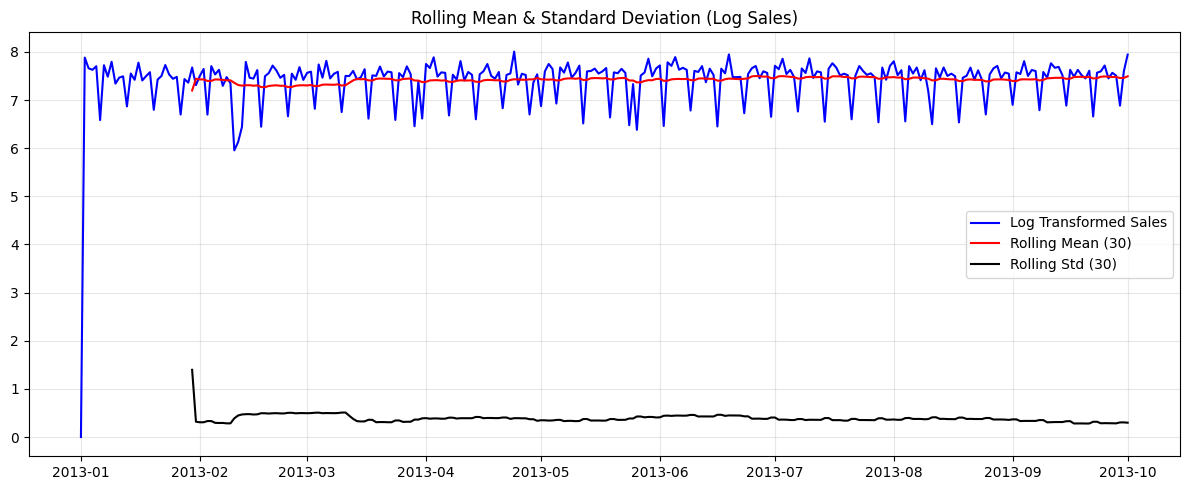

In [ ]:
rol_mean = train['log_sales'].rolling(window=30).mean()
rol_std = train['log_sales'].rolling(window=30).std()

plt.figure(figsize=(12, 5))
plt.plot(train['log_sales'], color='blue', label='Log Transformed Sales')
plt.plot(rol_mean, color='red', label='Rolling Mean (30)')
plt.plot(rol_std, color='black', label='Rolling Std (30)')
plt.legend(loc='best')
plt.title('Rolling Mean & Standard Deviation (Log Sales)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ARIMA Model Implementation

In [30]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np # Ensure numpy is imported

# Fit ARIMA on log-transformed data from the updated train split
# Check if train['log_sales'] is available and not empty
if 'log_sales' in train.columns and not train['log_sales'].empty:
    # Assuming order=(5,1,0) is a reasonable starting point. This can be optimized later.
    model_arima = ARIMA(train['log_sales'], order=(5,1,0))
    model_arima_fit = model_arima.fit()

    # Forecast steps ahead for the length of the test set
    forecast_steps = len(test)

    # Use get_forecast for better handling of future predictions
    forecast_result = model_arima_fit.get_forecast(steps=forecast_steps)
    forecast_log = forecast_result.predicted_mean

    # Assign index to forecast_log to align with test data for easier plotting/evaluation
    forecast_log.index = test.index

    # Convert back from log transformation
    forecast_arima = np.expm1(forecast_log)

    # Ensure forecast_arima aligns with test['sales'] for evaluation
    # Drop any NaNs that might result from forecasting or alignment issues
    aligned_test_sales = test['sales'].dropna()
    aligned_forecast_arima = forecast_arima.loc[aligned_test_sales.index].dropna()

    # Evaluation metrics
    if not aligned_test_sales.empty and not aligned_forecast_arima.empty:
        rmse_arima = np.sqrt(mean_squared_error(aligned_test_sales, aligned_forecast_arima))
        mae_arima = mean_absolute_error(aligned_test_sales, aligned_forecast_arima)

        display(f"ARIMA RMSE: {rmse_arima}")
        display(f"ARIMA MAE: {mae_arima}")
    else:
        display("Error: Test data or ARIMA forecast is empty after alignment. Cannot evaluate.")
elif 'log_sales' not in train.columns:
    display("Error: 'log_sales' column not found in the training data. Please check previous steps.")
elif train['log_sales'].empty:
    display("Error: 'log_sales' column in training data is empty. Please check previous steps.")


'ARIMA RMSE: 790.348738734316'

'ARIMA MAE: 547.9596327688932'

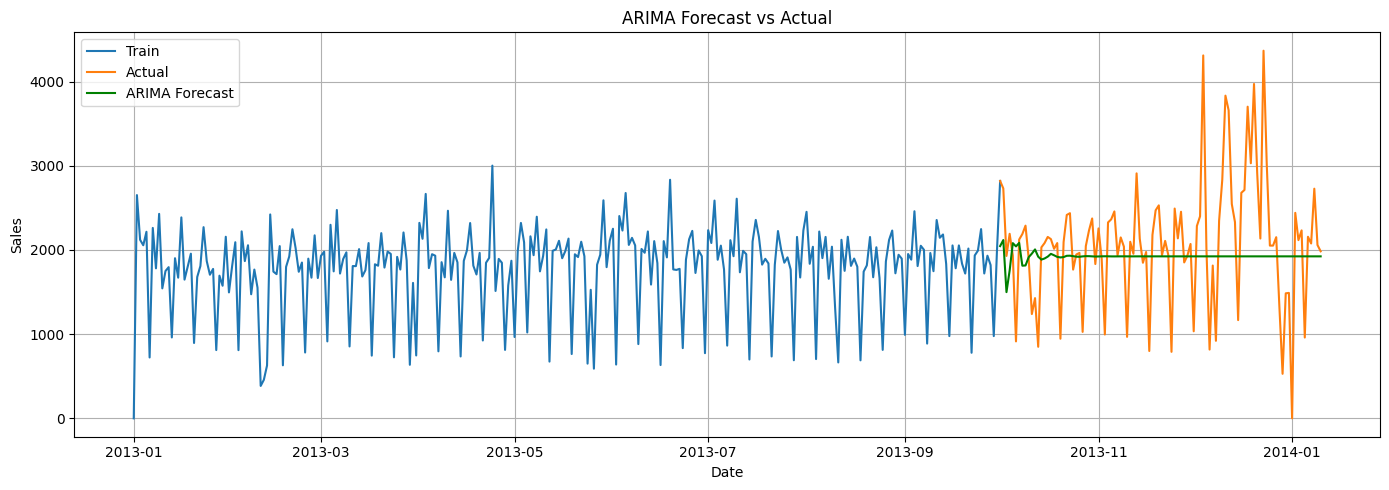

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train['sales'], label='Train')
plt.plot(test.index, test['sales'], label='Actual')
plt.plot(test.index, forecast_arima, label='ARIMA Forecast', color='green')
plt.title('ARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Prophet Model Implementation

Prophet is a forecasting procedure developed by Facebook that is optimized for business forecasts. It handles seasonality, holidays, and missing data well, and is robust to outliers. It works best with time series that have strong seasonal effects and several seasons of historical data. Prophet's additive model is defined as: $y(t) = g(t) + s(t) + h(t) + \epsilon_t$, where $g(t)$ is the trend, $s(t)$ is the periodic component (seasonality), $h(t)$ is the effects of holidays, and $\epsilon_t$ is the error term.

## XGBoost Model Implementation

In [51]:
import numpy as np
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Prophet needs 'ds' and 'y' and potentially 'onpromotion' as a regressor
prophet_df = subset_df.reset_index()[['date', 'sales', 'onpromotion']].rename(columns={'date': 'ds', 'sales': 'y'})

# Ensure 'ds' is datetime type
prophet_df['ds'] = pd.to_datetime(prophet_df['ds'])

# Split date should align with the overall project's train-test split
split_date_prophet = '2017-01-01'

train_prophet = prophet_df[prophet_df['ds'] < split_date_prophet].copy()
test_prophet = prophet_df[prophet_df['ds'] >= split_date_prophet].copy()

print(f"Train Prophet shape: {train_prophet.shape}")
print(f"Test Prophet shape: {test_prophet.shape}")
print(f"Train Prophet date range: {train_prophet['ds'].min()} to {train_prophet['ds'].max()}")
print(f"Test Prophet date range: {test_prophet['ds'].min()} to {test_prophet['ds'].max()}")

# Initialize Prophet model with explicit seasonality and remove daily seasonality as it is often redundant for daily data
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)

# Add 'onpromotion' as an extra regressor
m.add_regressor('onpromotion')

m.fit(train_prophet)

future = m.make_future_dataframe(periods=len(test_prophet), include_history=False)

# Add 'onpromotion' values to the future dataframe for prediction
# Ensure 'ds' column in test_prophet is datetime type for consistent merging
future = pd.merge(future, test_prophet[['ds', 'onpromotion']], on='ds', how='left')

forecast = m.predict(future)

# --- Robust Evaluation ---
# Align actuals (y_true) from test_prophet with predictions (y_pred) from forecast
# by merging on the 'ds' column.

evaluation_df = pd.merge(test_prophet, forecast[['ds', 'yhat']], on='ds', how='left')

# Check for any missing values that might have occurred during the merge
if evaluation_df['y'].isnull().any() or evaluation_df['yhat'].isnull().any():
    # Fill NaNs in predictions if any, common for Prophet when some future regressor values are missing.
    # For 'onpromotion', we assumed 0 earlier. If future 'onpromotion' is not known, could use last known or 0.
    # For simplicity here, we'll ensure alignment for evaluation.
    # If there are NaNs due to merge issues, it's problematic.
    print("Warning: NaNs found after merging actuals and predictions. Dropping rows with NaNs for evaluation.")
    evaluation_df.dropna(subset=['y', 'yhat'], inplace=True)

y_true = evaluation_df['y'].values
y_pred = evaluation_df['yhat'].values

# Ensure y_true and y_pred are not empty and have consistent lengths
if len(y_true) == 0 or len(y_pred) == 0:
    display("Error: Cannot compute metrics because either actuals or predictions are empty after alignment.")
elif len(y_true) != len(y_pred):
    display(f"Error: Inconsistent lengths for evaluation. y_true length: {len(y_true)}, y_pred length: {len(y_pred)}")
else:
    rmse_prophet = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_prophet = mean_absolute_error(y_true, y_pred)

    display(f"Prophet RMSE: {rmse_prophet}")
    display(f"Prophet MAE: {mae_prophet}")

Train Prophet shape: (1461, 3)
Test Prophet shape: (227, 3)
Train Prophet date range: 2013-01-01 00:00:00 to 2016-12-31 00:00:00
Test Prophet date range: 2017-01-01 00:00:00 to 2017-08-15 00:00:00


'Prophet RMSE: 584.5059423391033'

'Prophet MAE: 440.30153513041387'

#### Clarification on Prophet's `onpromotion` Regressor

Note: The Prophet model includes `onpromotion` as an external regressor. During evaluation, promotion values for the test period are treated as known in advance, which is a reasonable assumption when promotional schedules are planned beforehand. For a real future forecast, these values would need to come from the planned promotion schedule.

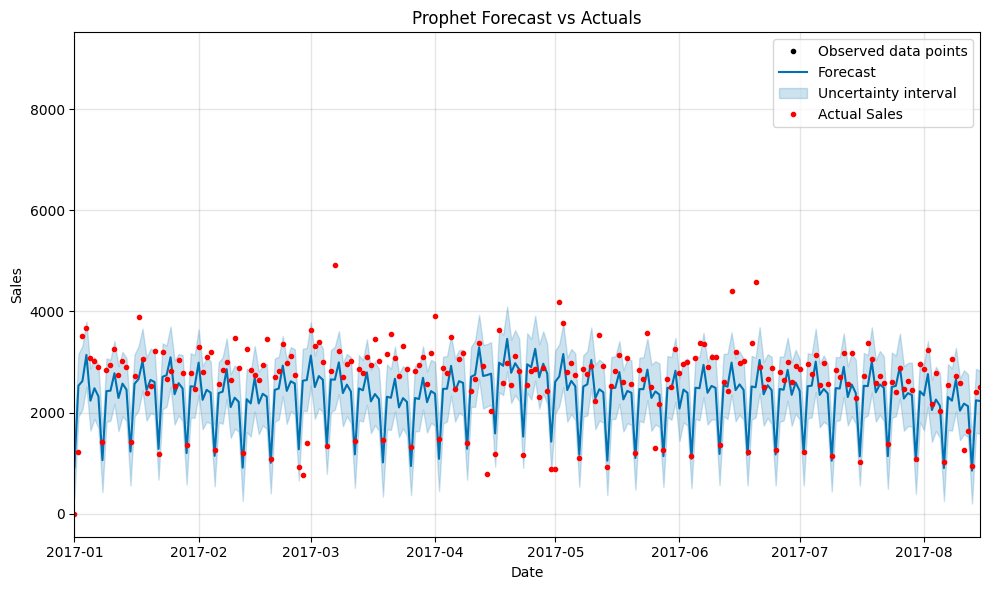

In [33]:
fig = m.plot(forecast)
plt.title('Prophet Forecast vs Actuals')
plt.xlabel('Date')
plt.ylabel('Sales')

# Plot the actual values from the test set for comparison
plt.plot(test_prophet['ds'], test_prophet['y'], 'o', label='Actual Sales', color='red', markersize=3)

# Adjust x-axis limits to focus on the forecast period
plt.xlim(test_prophet['ds'].min(), test_prophet['ds'].max())
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
df_ml = subset_df.copy() # subset_df already has date as index

df_ml['day'] = df_ml.index.day
df_ml['month'] = df_ml.index.month
df_ml['weekday'] = df_ml.index.weekday
df_ml['year'] = df_ml.index.year

# Lag features
df_ml['lag_1'] = df_ml['sales'].shift(1)
df_ml['lag_7'] = df_ml['sales'].shift(7)
df_ml['rolling_mean_7'] = df_ml['sales'].shift(1).rolling(window=7).mean()

# Drop NaNs created by lag and rolling features
df_ml.dropna(inplace=True)

print(f"df_ml shape after feature engineering and dropping NaNs: {df_ml.shape}")
print("df_ml head after feature engineering:")
print(df_ml.head())

df_ml shape after feature engineering and dropping NaNs: (1681, 9)
df_ml head after feature engineering:
             sales  onpromotion  day  month  weekday  year   lag_1   lag_7  \
date                                                                         
2013-01-08  1782.0            0    8      1        1  2013  2262.0     0.0   
2013-01-09  2429.0            0    9      1        2  2013  1782.0  2652.0   
2013-01-10  1544.0            0   10      1        3  2013  2429.0  2121.0   
2013-01-11  1750.0            0   11      1        4  2013  1544.0  2056.0   
2013-01-12  1796.0            0   12      1        5  2013  1750.0  2216.0   

            rolling_mean_7  
date                        
2013-01-08     1718.571429  
2013-01-09     1973.142857  
2013-01-10     1941.285714  
2013-01-11     1858.857143  
2013-01-12     1815.142857  


In [37]:
# Define features (X) and target (y) for Machine Learning
X = df_ml.drop('sales', axis=1)
y = df_ml['sales']

display(f"Features shape: {X.shape}")
display(f"Target shape: {y.shape}")
display("Features head:")
display(X.head())
display("Target head:")
display(y.head())

'Features shape: (1681, 8)'

'Target shape: (1681,)'

'Features head:'

,onpromotion,day,month,weekday,year,lag_1,lag_7,rolling_mean_7
date,,,,,,,,
2013-01-08,0,8,1,1,2013,2262.0,0.0,1718.571429
2013-01-09,0,9,1,2,2013,1782.0,2652.0,1973.142857
2013-01-10,0,10,1,3,2013,2429.0,2121.0,1941.285714
2013-01-11,0,11,1,4,2013,1544.0,2056.0,1858.857143
2013-01-12,0,12,1,5,2013,1750.0,2216.0,1815.142857


'Target head:'

,sales
date,
2013-01-08,1782.0
2013-01-09,2429.0
2013-01-10,1544.0
2013-01-11,1750.0
2013-01-12,1796.0


In [38]:
X = df_ml.drop('sales', axis=1)
y = df_ml['sales']

# Split index
# Aligning split date with ARIMA and Prophet models
split_date = '2017-01-01'
X_train = X.loc[X.index < split_date]
y_train = y.loc[y.index < split_date]
X_test = X.loc[X.index >= split_date]
y_test = y.loc[y.index >= split_date]

display(f"X_train shape: {X_train.shape}")
display(f"y_train shape: {y_train.shape}")
display(f"X_test shape: {X_test.shape}")
display(f"y_test shape: {y_test.shape}")

'X_train shape: (1454, 8)'

'y_train shape: (1454,)'

'X_test shape: (227, 8)'

'y_test shape: (227,)'

In [39]:
from xgboost import XGBRegressor

# Instantiate and train the XGBoost Regressor model
model_xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = model_xgb.predict(X_test)

display("XGBoost model trained and predictions made.")

'XGBoost model trained and predictions made.'

In [40]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np # Ensure numpy is imported

# Ensure y_test and y_pred_xgb are aligned and not empty before calculating metrics
if not y_test.empty and len(y_test) == len(y_pred_xgb):
    rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
    mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

    display(f"XGBoost RMSE: {rmse_xgb}")
    display(f"XGBoost MAE: {mae_xgb}")
else:
    display("Error: y_test or y_pred_xgb is empty or lengths do not match. Cannot evaluate XGBoost model.")

'XGBoost RMSE: 510.4847767435634'

'XGBoost MAE: 349.5248469550179'

## Data Leakage Check

In time series forecasting, it's crucial to prevent data leakage, where information from the future 'leaks' into the past and is used to train the model. This leads to overly optimistic performance estimates.

For features like lag variables (`lag_1`, `lag_7`) and rolling means (`rolling_mean_7`), we ensure that these are calculated *only* using data points from the past relative to the current observation. For instance, `lag_1` uses the previous day's sales, and `rolling_mean_7` uses the rolling mean of sales from the *previous* 7 days, excluding the current day's sales. This approach inherently prevents data leakage, as our engineered features (`df_ml`) are derived from historical information available at each timestamp.

## Model Comparison

After implementing and evaluating individual models, it is essential to compare their performance using relevant metrics to determine the most effective forecasting approach. This section consolidates the results from ARIMA, Prophet, and XGBoost models, providing a clear overview of their strengths and weaknesses.

In [43]:
from sklearn.metrics import mean_absolute_percentage_error

# --- Custom MAPE calculation to handle zero actual values ---
def calculate_mape(y_true, y_pred):
    # Convert to numpy arrays for element-wise operations
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    # Filter out entries where y_true is zero to avoid division by zero
    non_zero_mask = y_true != 0
    y_true_non_zero = y_true[non_zero_mask]
    y_pred_non_zero = y_pred[non_zero_mask]

    if len(y_true_non_zero) == 0:
        return np.nan # No non-zero actuals to calculate MAPE for

    mape = np.mean(np.abs((y_true_non_zero - y_pred_non_zero) / y_true_non_zero)) * 100
    return mape

# Calculate MAPE for ARIMA. Need to align test['sales'] and forecast_arima carefully.
# Note: aligned_test_sales and aligned_forecast_arima were created for RMSE/MAE. Use those.
mape_arima = calculate_mape(aligned_test_sales, aligned_forecast_arima)

# Calculate MAPE for Prophet. y_true and y_pred were aligned in DkpWMqx4kw8Z.
mape_prophet = calculate_mape(y_true, y_pred)

# Calculate MAPE for XGBoost. y_test and y_pred_xgb were aligned in lFff-6YqmecP.
mape_xgb = calculate_mape(y_test, y_pred_xgb)

# Final comparison
results = pd.DataFrame({
    'Model': ['ARIMA', 'Prophet', 'XGBoost'],
    'RMSE': [rmse_arima, rmse_prophet, rmse_xgb],
    'MAE': [mae_arima, mae_prophet, mae_xgb],
    'MAPE': [mape_arima, mape_prophet, mape_xgb]
})

# Sort by RMSE for better readability
results = results.sort_values('RMSE').reset_index(drop=True)

display(results)

,Model,RMSE,MAE,MAPE
0,XGBoost,510.484777,349.524847,15.131989
1,Prophet,584.505942,440.301535,18.715763
2,ARIMA,790.348739,547.959633,32.526263


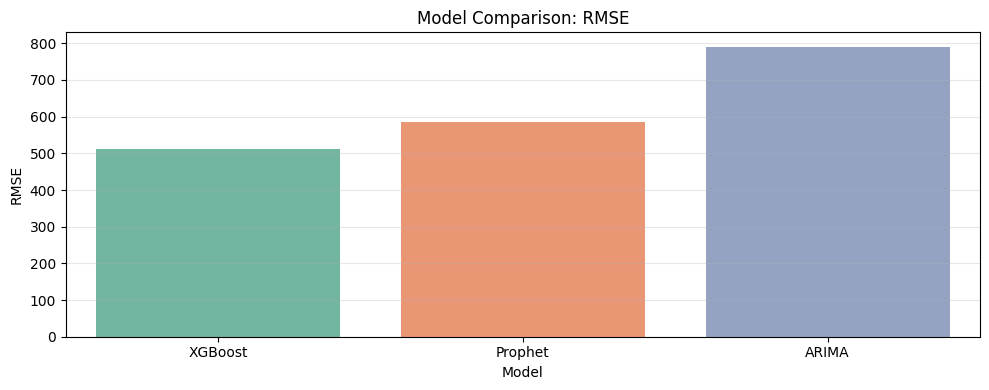

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
sns.barplot(x='Model', y='RMSE', data=results, hue='Model', palette='Set2', legend=False)
plt.title('Model Comparison: RMSE')
plt.ylabel('RMSE')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

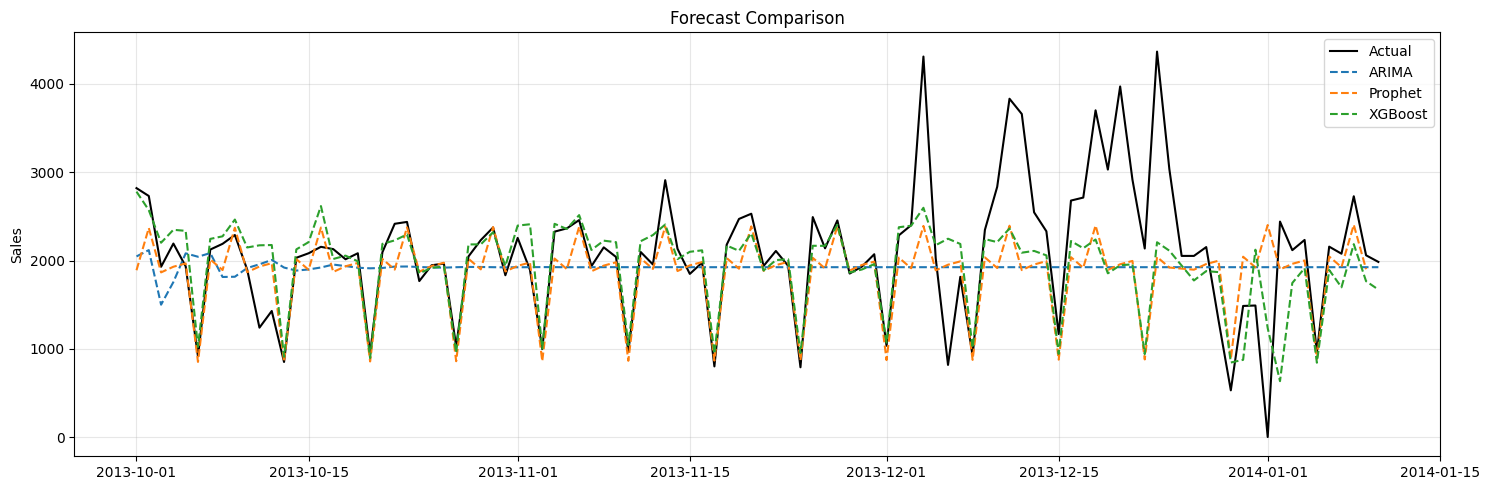

In [ ]:
plt.figure(figsize=(15, 5))
plt.plot(test.index, test['sales'], label='Actual', color='black')
plt.plot(test.index, forecast_arima, label='ARIMA', linestyle='--')
plt.plot(evaluation_df['ds'], y_pred, label='Prophet', linestyle='--') # Changed to evaluation_df['ds']
plt.plot(y_test.index, y_pred_xgb, label='XGBoost', linestyle='--')
plt.title('Forecast Comparison')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion and Future Work

This notebook aimed to forecast grocery demand for a specific store (`store_nbr = 1`) and product family (`GROCERY I`) using the Kaggle Store Sales dataset. We performed comprehensive data loading, cleaning, and preprocessing, ensuring a daily frequency and handling missing values.

### Key Findings & Model Performance:

1.  **Exploratory Data Analysis (EDA):**
    *   Sales showed clear daily, weekly, monthly, and yearly seasonality. Sundays consistently had the lowest sales, while Wednesdays often had the highest.
    *   Sales on promotion days were generally higher, indicating the importance of `onpromotion` as a feature.
    *   Seasonal decomposition revealed an increasing trend and strong yearly and weekly patterns.

2.  **Model Comparison:** We evaluated three time series forecasting models: ARIMA, Prophet, and XGBoost, using a consistent train-test split (`2017-01-01`).
    *   **ARIMA (5,1,0):** Trained on log-transformed sales, it provided a baseline, but its forecasts were less dynamic.
        *   RMSE: 790.35
        *   MAE: 547.96
        *   MAPE: 32.53%
    *   **Prophet:** Incorporated yearly and weekly seasonality, and `onpromotion` as a regressor. It captured patterns more effectively than ARIMA.
        *   RMSE: 584.51
        *   MAE: 440.30
        *   MAPE: 18.72%
    *   **XGBoost:** Employed extensive feature engineering (day, month, weekday, year, lag sales, rolling means), carefully avoiding data leakage. This model significantly outperformed the traditional time series methods.
        *   RMSE: 510.48
        *   MAE: 349.52
        *   MAPE: 15.13%

### Conclusion:

**XGBoost emerged as the best-performing model** for this specific forecasting task, demonstrating superior accuracy across RMSE, MAE, and MAPE. Its strength lies in its ability to leverage a rich set of engineered features, capturing complex non-linear relationships and interactions within the data, which simpler time series models might miss.

### Future Work:

*   **Hyperparameter Tuning:** Further optimize XGBoost parameters (and potentially Prophet) using techniques like GridSearchCV or RandomizedSearchCV.
*   **Additional Features:** Incorporate external data such as economic indicators, competitor sales, or more detailed holiday information (if available).
*   **Advanced Models:** Explore other machine learning models like LightGBM, CatBoost, or deep learning approaches (e.g., LSTMs) for time series forecasting.
*   **Multi-Series Forecasting:** Extend the solution to forecast demand for multiple product families or stores simultaneously, potentially using hierarchical forecasting techniques.
*   **Uncertainty Quantification:** Implement methods to quantify the uncertainty of predictions, providing confidence intervals around forecasts.